# Dataset EDA — FFHQ-512 face captions

Exploratory analysis of the training dataset at `/workspace/data/ffhq512/`: the
70k face images and their sidecar `.txt` captions that
`imagegen.data.dataset.ImageFolderDataset` feeds to the diffusion model.

Covers caption coverage & quality, caption length / vocabulary distributions,
image properties (size, mode, brightness) on a random sample, a visual
image↔caption grid, and a sanity check that what we inspect here matches the
normalized tensor the model actually consumes.

In [1]:
# --- Config & imports ---
import os
import sys
import random
from pathlib import Path
from collections import Counter
from concurrent.futures import ThreadPoolExecutor

import numpy as np
import polars as pl
import matplotlib.pyplot as plt
from PIL import Image, ImageDraw
from IPython.display import display

# Make the project importable in any kernel (notebook runs from notebooks/).
REPO_ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "pyproject.toml").exists())
sys.path.insert(0, str(REPO_ROOT / "src"))

from imagegen.data.dataset import IMAGE_EXTS, ImageFolderDataset  # noqa: E402
from imagegen.captions import clean_caption  # noqa: E402

ROOT = Path("/workspace/data/ffhq512")   # data.root in configs/full_sd21.yaml
TRIGGER_PROMPT = "a high-quality photo of a person's face"  # fallback when caption missing
PIXEL_SAMPLE_N = 1500    # images sampled for pixel-level stats (size/brightness)
GRID_N = 12              # images shown in the visual sample grid
SEED = 42

pl.Config.set_tbl_rows(20)
print(f"Dataset root: {ROOT}  (exists: {ROOT.exists()})")

/root/ImageGenExperiments/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Dataset root: /workspace/data/ffhq512  (exists: True)


## File discovery & caption coverage

Discover every image and read its sidecar `<image>.txt` into a polars DataFrame,
covering the **whole** dataset. The dataset filesystem has high per-file latency,
so instead of a serial `rglob` over ~140k paths we `scandir` each shard and read
captions with a thread pool — the reads are latency-bound and parallelize well
(~20s vs. ~15min serial).

In [2]:
def _scan(d):
    """List image paths in one shard dir (single scandir pass, same IMAGE_EXTS)."""
    imgs = []
    for e in os.scandir(d):
        if os.path.splitext(e.name)[1].lower() in IMAGE_EXTS:
            imgs.append(e.path)
    return imgs

def _read_caption(p):
    sidecar = os.path.splitext(p)[0] + ".txt"
    try:
        with open(sidecar, encoding="utf-8") as f:
            return f.read().strip()
    except FileNotFoundError:
        return ""

shard_dirs = [e.path for e in os.scandir(ROOT) if e.is_dir()] or [str(ROOT)]
paths = []
with ThreadPoolExecutor(max_workers=32) as ex:
    for imgs in ex.map(_scan, shard_dirs):
        paths.extend(imgs)
paths.sort()  # match ImageFolderDataset's sorted ordering

with ThreadPoolExecutor(max_workers=64) as ex:
    captions = list(ex.map(_read_caption, paths))

df = pl.DataFrame({
    "path": paths,
    "shard": [os.path.basename(os.path.dirname(p)) for p in paths],
    "has_caption": [bool(c) for c in captions],
    "caption": captions,
    "caption_len_chars": [len(c) for c in captions],
    "caption_word_count": [len(c.split()) for c in captions],
})
n_total = df.height
n_caption = int(df["has_caption"].sum())
print(f"images discovered : {n_total:,}")
print(f"with caption      : {n_caption:,} ({n_caption / n_total:.1%})")
print(f"missing caption   : {n_total - n_caption:,}  (would fall back to TRIGGER_PROMPT)")
print(f"shards            : {df['shard'].n_unique()}")
df.head()

images discovered : 70,000
with caption      : 69,998 (100.0%)
missing caption   : 2  (would fall back to TRIGGER_PROMPT)
shards            : 54


path,shard,has_caption,caption,caption_len_chars,caption_word_count
str,str,bool,str,i64,i64
"""/workspace/data/ffhq512/000/00…","""000""",true,"""a photography of a baby in a b…",63,13
"""/workspace/data/ffhq512/000/00…","""000""",true,"""a photography of a woman smili…",59,12
"""/workspace/data/ffhq512/000/00…","""000""",true,"""a photography of a woman with …",59,13
"""/workspace/data/ffhq512/000/00…","""000""",true,"""a photography of a little girl…",61,12
"""/workspace/data/ffhq512/000/00…","""000""",true,"""a photography of a woman in a …",54,12


statistic,shard,len
str,str,f64
"""count""","""54""",54.0
"""null_count""","""0""",0.0
"""mean""",null,1296.296296
"""std""",null,0.460911
"""min""","""000""",1296.0
"""25%""",null,1296.0
"""50%""",null,1296.0
"""75%""",null,1297.0
"""max""","""053""",1297.0


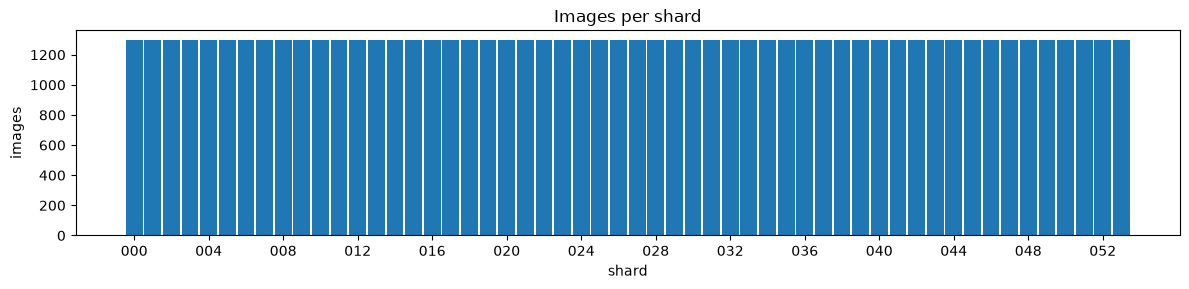

In [3]:
# Images per shard — should be roughly balanced (~1.3k each).
per_shard = df.group_by("shard").len().sort("shard")
display(per_shard.describe())

fig, ax = plt.subplots(figsize=(12, 3))
ax.bar(per_shard["shard"], per_shard["len"], width=0.9)
ax.set_xlabel("shard")
ax.set_ylabel("images")
ax.set_title("Images per shard")
ax.set_xticks(ax.get_xticks()[::4])
plt.tight_layout()
plt.show()

## Dataset integrity

Surface anything that would degrade training: missing/empty captions (silent
trigger-prompt fallback), exact-duplicate captions, and captions still carrying
the BLIP filler artifacts (`there is`, `arafed`, …) that
`imagegen.captions.clean_caption` is meant to have stripped.

In [4]:
cap = df.filter(pl.col("has_caption"))  # rows with a real caption

# Most common exact-duplicate captions.
dupes = (cap.group_by("caption").len()
            .filter(pl.col("len") > 1).sort("len", descending=True))
print(f"distinct captions       : {cap['caption'].n_unique():,}")
print(f"captions appearing >1x   : {dupes.height:,}")
display(dupes.head(10))

# Residual filler / non-canonical captions: clean_caption should be a no-op already.
changed = sum(clean_caption(c) != c for c in cap["caption"].to_list())
print(f"captions changed by clean_caption(): {changed:,} "
      f"({changed / cap.height:.2%}) — expect ~0 if already normalized")
for needle in ("there is", "there are", "they are", "arafed"):
    n = cap.filter(pl.col("caption").str.contains(needle)).height
    print(f"  contains {needle!r:12}: {n:,}")

distinct captions       : 28,385
captions appearing >1x   : 6,173


caption,len
str,u32
"""a photography of a woman with …",1063
"""a photography of a man in a su…",922
"""a photography of a man in a su…",625
"""a photography of a man and a w…",513
"""a photography of a man with gl…",462
"""a photography of a woman with …",433
"""a photography of a woman smili…",422
"""a photography of a woman with …",393
"""a photography of a woman with …",364


captions changed by clean_caption(): 1 (0.00%) — expect ~0 if already normalized
  contains 'there is'  : 0
  contains 'there are' : 0
  contains 'they are'  : 0
  contains 'arafed'    : 0


## Caption length distributions

How long are the captions, in characters and in words? Skewed or truncated
captions are worth knowing about before tuning the text-encoder side.

statistic,caption_len_chars,caption_word_count
str,f64,f64
"""count""",70000.0,70000.0
"""null_count""",0.0,0.0
"""mean""",58.166643,12.177314
"""std""",6.963566,1.37097
"""min""",0.0,0.0
"""25%""",53.0,11.0
"""50%""",57.0,12.0
"""75%""",62.0,13.0
"""max""",97.0,19.0


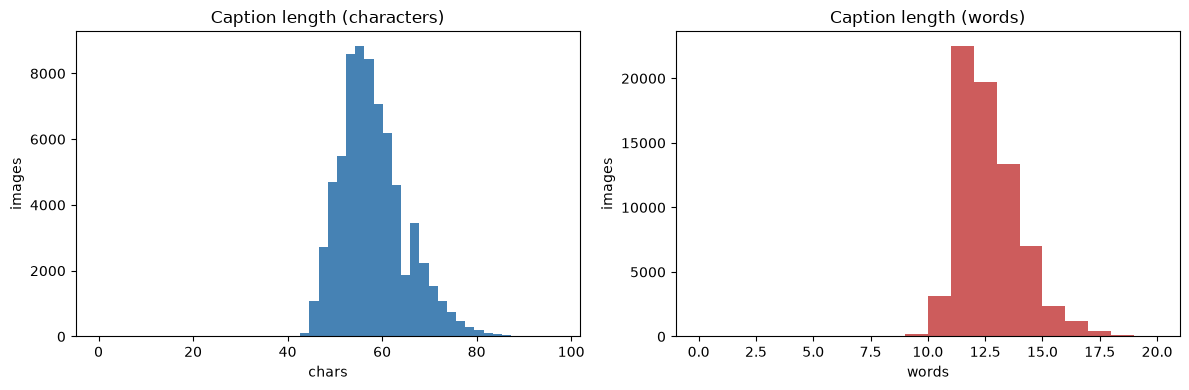

In [5]:
display(df.select(["caption_len_chars", "caption_word_count"]).describe())

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(df["caption_len_chars"], bins=50, color="steelblue")
axes[0].set_title("Caption length (characters)")
axes[0].set_xlabel("chars")
axes[1].hist(df["caption_word_count"], bins=range(0, df["caption_word_count"].max() + 2),
             color="indianred")
axes[1].set_title("Caption length (words)")
axes[1].set_xlabel("words")
for a in axes:
    a.set_ylabel("images")
plt.tight_layout()
plt.show()

## Caption vocabulary

Word-frequency over all captions: the dominant tokens reveal what the model is
mostly being conditioned on (and confirm this is a face dataset).

vocabulary size: 1,790  |  total tokens: 852,412


word,count
str,i64
"""a""",227027
"""of""",73328
"""photography""",69998
"""with""",48991
"""and""",47141
"""woman""",32278
"""man""",28162
"""smiling""",16646
"""in""",15638


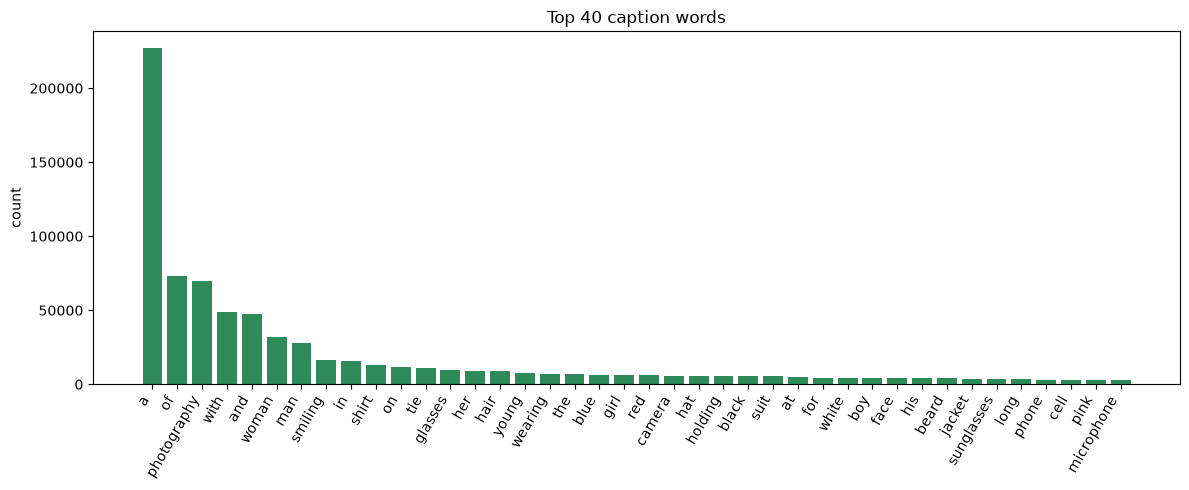

In [6]:
tokens = Counter()
for c in cap["caption"].to_list():
    tokens.update(c.lower().split())

print(f"vocabulary size: {len(tokens):,}  |  total tokens: {sum(tokens.values()):,}")
top = pl.DataFrame({"word": [w for w, _ in tokens.most_common(40)],
                    "count": [n for _, n in tokens.most_common(40)]})
display(top.head(15))

fig, ax = plt.subplots(figsize=(12, 5))
ax.bar(top["word"], top["count"], color="seagreen")
ax.set_title("Top 40 caption words")
ax.set_ylabel("count")
plt.xticks(rotation=60, ha="right")
plt.tight_layout()
plt.show()

## Image properties (sampled)

Pixel-level stats over a reproducible random sample of `PIXEL_SAMPLE_N` images
(opening 70k PNGs would be slow). We expect uniform 512×512 RGB; brightness /
per-channel means describe the overall tone of the dataset.

sampled images   : 1,500
unique (w,h)     : [(512, 512)]


statistic,brightness,mean_r,mean_g,mean_b
str,f64,f64,f64,f64
"""count""",1500.0,1500.0,1500.0,1500.0
"""null_count""",0.0,0.0,0.0,0.0
"""mean""",112.938958,133.208686,108.387987,97.220201
"""std""",27.11173,29.520262,27.855533,29.151923
"""min""",35.422039,44.314697,32.569824,12.024658
"""25%""",94.866859,113.956055,89.080078,77.273193
"""50%""",111.889488,132.423828,107.489258,95.251221
"""75%""",130.540527,151.955566,126.193115,116.75
"""max""",200.025146,225.578857,197.516113,189.658936


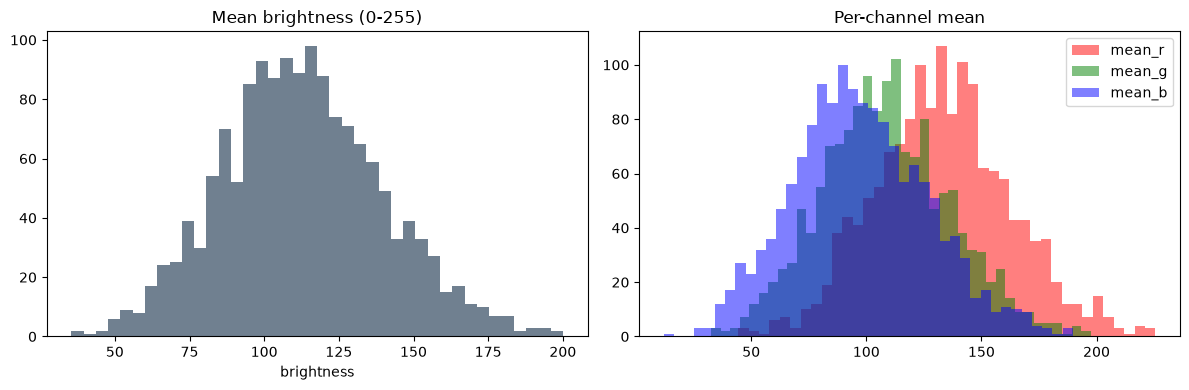

In [7]:
rng = random.Random(SEED)
sample_paths = rng.sample(paths, min(PIXEL_SAMPLE_N, len(paths)))

def _img_stats(p):
    im = Image.open(p).convert("RGB")
    w, h = im.size
    arr = np.asarray(im.resize((64, 64)), dtype=np.float32)  # downscale for speed
    return {"width": w, "height": h,
            "mean_r": float(arr[..., 0].mean()), "mean_g": float(arr[..., 1].mean()),
            "mean_b": float(arr[..., 2].mean()), "brightness": float(arr.mean())}

with ThreadPoolExecutor(max_workers=16) as ex:  # latency-bound reads parallelize well
    rows = list(ex.map(_img_stats, sample_paths))

img_df = pl.DataFrame(rows)
print(f"sampled images   : {img_df.height:,}")
print("unique (w,h)     :", img_df.select(["width", "height"]).unique().rows())
display(img_df.select(["brightness", "mean_r", "mean_g", "mean_b"]).describe())

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(img_df["brightness"], bins=40, color="slategray")
axes[0].set_title("Mean brightness (0-255)")
axes[0].set_xlabel("brightness")
for ch, color in [("mean_r", "red"), ("mean_g", "green"), ("mean_b", "blue")]:
    axes[1].hist(img_df[ch], bins=40, alpha=0.5, color=color, label=ch)
axes[1].set_title("Per-channel mean")
axes[1].legend()
plt.tight_layout()
plt.show()

## Visual sample grid

A handful of random image↔caption pairs to eyeball alignment and overall image
quality.

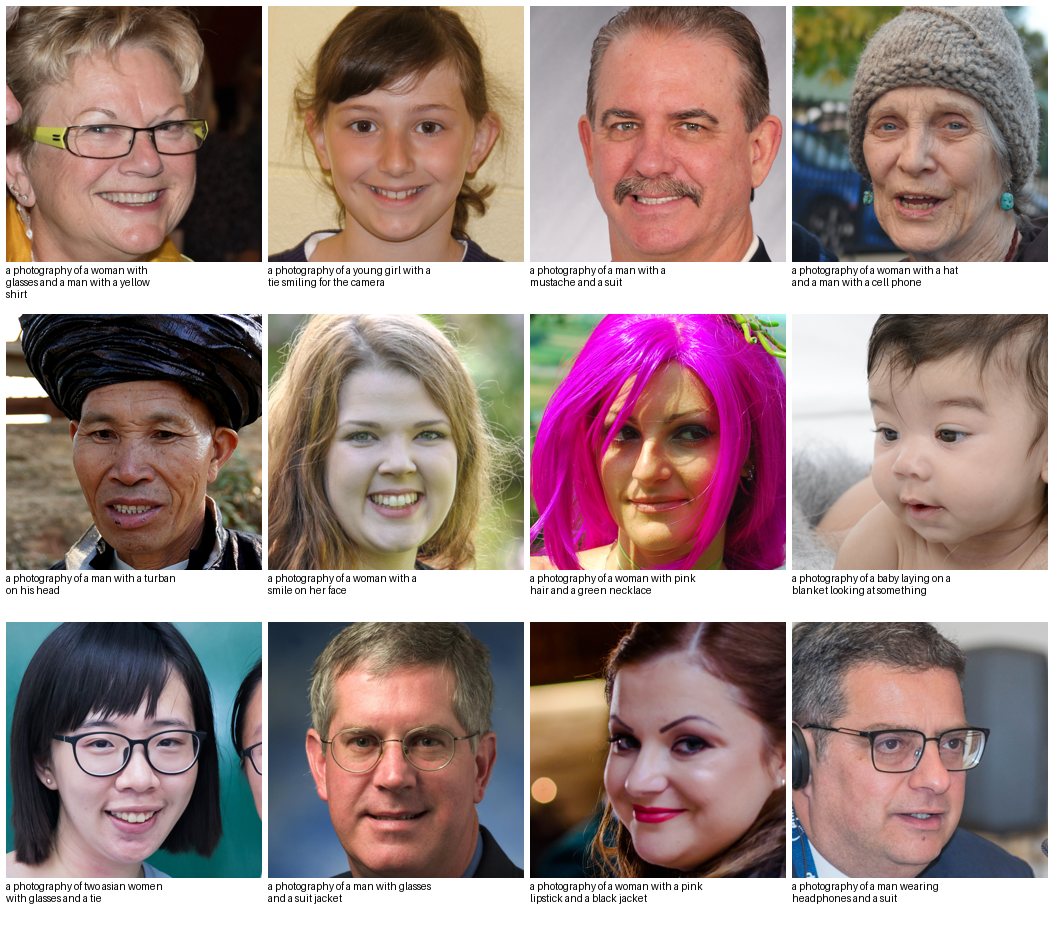

In [8]:
def caption_grid(items, thumb=256, pad=6, cap_h=46, cols=4):
    """Grid of (path, caption) with the caption wrapped under each thumbnail."""
    rows = (len(items) + cols - 1) // cols
    cell_w, cell_h = thumb + pad, thumb + cap_h + pad
    canvas = Image.new("RGB", (cols * cell_w + pad, rows * cell_h + pad), "white")
    draw = ImageDraw.Draw(canvas)
    for i, (path, caption) in enumerate(items):
        r, c = divmod(i, cols)
        x, y = pad + c * cell_w, pad + r * cell_h
        canvas.paste(Image.open(path).convert("RGB").resize((thumb, thumb)), (x, y))
        words, line, ty = caption.split(), "", y + thumb + 2
        for w in words:                       # naive word-wrap (~36 chars/line)
            if len(line) + len(w) + 1 > 36:
                draw.text((x, ty), line, fill="black")
                ty += 12
                line = w
            else:
                line = f"{line} {w}".strip()
        draw.text((x, ty), line, fill="black")
    return canvas

grid_paths = rng.sample(paths, GRID_N)
items = [(p, _read_caption(p) or "(no caption)") for p in grid_paths]  # _read_caption from discovery cell
display(caption_grid(items))

## Pipeline sanity check

Confirm the EDA view matches what training consumes: load through the real
`ImageFolderDataset` and verify the tensor shape, dtype, and `[-1, 1]` range.

In [9]:
ds = ImageFolderDataset(root=ROOT, caption=TRIGGER_PROMPT, image_size=512, limit=8)
sample = ds[0]
px = sample["pixel_values"]
print(f"dataset length (limited) : {len(ds)}")
print(f"pixel_values shape       : {tuple(px.shape)}  dtype={px.dtype}")
print(f"value range              : [{px.min():.3f}, {px.max():.3f}]  (expect within [-1, 1])")
print(f"caption                  : {sample['caption']!r}")
assert tuple(px.shape) == (3, 512, 512)
assert -1.01 <= float(px.min()) and float(px.max()) <= 1.01
print("OK — pipeline output matches expectations.")

dataset length (limited) : 8
pixel_values shape       : (3, 512, 512)  dtype=torch.float32
value range              : [-1.000, 1.000]  (expect within [-1, 1])
caption                  : 'a photography of a baby in a blue blanket with a stuffed animal'
OK — pipeline output matches expectations.


## Summary

- **Scale:** ~70k images across the shard directories under `/workspace/data/ffhq512/`.
- **Caption coverage:** see the discovery cell — any uncaptioned images silently
  fall back to `TRIGGER_PROMPT` during training.
- **Caption quality:** `clean_caption()` should change ≈0 captions and filler
  (`there is` / `arafed`) should be absent, confirming normalization ran.
- **Length:** character/word distributions above; watch for a long tail.
- **Images:** sampled cells expect uniform 512×512 RGB; brightness/per-channel
  means describe dataset tone.
- **Pipeline:** the final cell confirms tensors are `(3, 512, 512)` in `[-1, 1]`.

_Fill in concrete numbers after a run._